In [404]:
import scanpy as sc
import pandas as pd

In [405]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import seaborn as sns

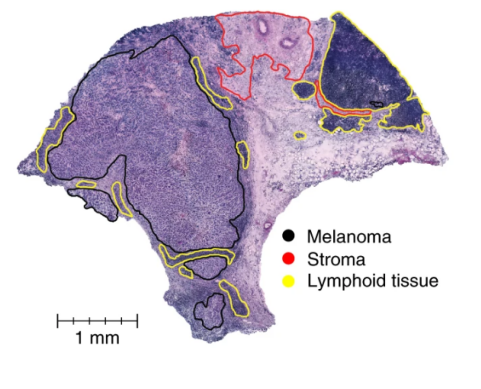

In [406]:
img = mpimg.imread("/scratch/lalonsoeste/PhD/SpatialTranscriptomics/data/spatial/BayesSpace/melanoma_thrane/processed/melanoma_rep1.png")

plt.imshow(img)
plt.axis("off")   # hides axes
plt.show()

# K=4 
## (3 annotated regions + 1 for unannotated)

In [407]:
adata = sc.read_h5ad("/scratch/lalonsoeste/PhD/SpatialTranscriptomics/data/spatial/BayesSpace/melanoma_thrane/processed/ST_mel1_rep2.h5ad")
adata.var_names_make_unique()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata

/scratch/lalonsoeste/envs/ST/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 293 × 16148
    obs: 'array_row', 'array_col', 'array_col_flipped'
    var: 'gene_id', 'ensemble_id'
    uns: 'log1p'
    obsm: 'spatial'

In [408]:
SIGNATURES = {
    "Tumor cells (surrounding)": ["CXCL10","WARS1","C1QB","GBP4","CXCL9"],
    "Tumor cells (center)": ["SPP1","HSPB1","ATP1A1","NDRG1","ANXA1"],
    "Stroma": ["MYL9","CFD","DCN","COL3A1","CH507-513H4.5"],
    "Lymphoid": ["LTB","CD79A","MS4A1","CCL21","CD79B"],
}

In [409]:
K=4

In [410]:
snmf_proportions = pd.read_csv(f"./K{K}/SNMF/SNMF_proportions.csv", index_col=0)
snmf_proportions

,V1,V2,V3,V4
7x15,0.092563,0.172999,0.429158,0.305280
7x16,0.110570,0.288698,0.347210,0.253522
7x17,0.207234,0.561182,0.185313,0.046270
7x18,0.592028,0.151189,0.202339,0.054444
8x13,0.033406,0.334917,0.545803,0.085874
...,...,...,...,...
27x18,0.461697,0.268025,0.257740,0.012537
27x19,0.493712,0.186811,0.312182,0.007295
27x20,0.285755,0.514008,0.198191,0.002046
27x21,0.061835,0.804433,0.133025,0.000706


In [411]:
adata.obs = pd.concat([adata.obs, snmf_proportions], axis=1)

In [412]:
snmf_signatures = pd.read_csv(f"./K{K}/SNMF/signatures.csv", index_col=0)
snmf_signatures

,V1,V2,V3,V4
PSME2,2.946165,3.757557,1.535375e+01,2.871984
CUEDC1,0.686745,0.184801,3.095448e-01,0.693781
RPLP1,224.261819,88.759127,4.017558e+01,36.259691
TM9SF3,0.705521,1.741438,1.951224e+00,1.709629
DEF8,2.118830,1.664301,1.166187e+00,1.354121
...,...,...,...,...
MICU3,0.350338,0.198431,0.000000e+00,0.000000
CTAGE5,0.243384,0.216817,0.000000e+00,0.000001
ALPL,0.000000,0.417160,1.714090e-41,0.000000
GPC3,0.000000,0.521521,0.000000e+00,0.000000


In [413]:
adata.var = pd.concat([adata.var, snmf_signatures], axis=1)

In [414]:
import numpy as np

snmf_z = (snmf_signatures - snmf_signatures.mean(axis=0)) / snmf_signatures.std(axis=0)

score_table = pd.DataFrame(index=SIGNATURES.keys(),
                           columns=snmf_z.columns,
                           dtype=float)

for comp in snmf_z.columns:
    for celltype, markers in SIGNATURES.items():
        valid = [g for g in markers if g in snmf_z.index]
        if len(valid) > 0:
            score_table.loc[celltype, comp] = (
                snmf_z.loc[valid, comp].mean() - snmf_z[comp].mean()
            )
        else:
            score_table.loc[celltype, comp] = -np.inf

# --------------------------------------------------
# 2️⃣ Annotation function
# --------------------------------------------------
def unique_assignment(score_table, threshold=0.2):
    
    # For each component, sort cell types by descending score
    ranked = {
        comp: score_table[comp].sort_values(ascending=False).index.tolist()
        for comp in score_table.columns
    }
    
    assigned_celltypes = set()
    final_assignment = {}
    
    # Sort components by their BEST score (descending)
    components_order = sorted(
        score_table.columns,
        key=lambda c: score_table[c].max(),
        reverse=True
    )
    
    for comp in components_order:
        for celltype in ranked[comp]:
            
            if score_table.loc[celltype, comp] < threshold:
                final_assignment[comp] = "ambiguous"
                break
            
            if celltype not in assigned_celltypes:
                final_assignment[comp] = celltype
                assigned_celltypes.add(celltype)
                break
        else:
            final_assignment[comp] = "ambiguous"
    
    return pd.Series(final_assignment)

# --------------------------------------------------
# 3️⃣ Apply to all components
# --------------------------------------------------
annotation = unique_assignment(score_table)

print(annotation)

V4         Tumor cells (center)
V3    Tumor cells (surrounding)
V1                       Stroma
V2                     Lymphoid
dtype: object


In [415]:
N_TOP_GENES = 5

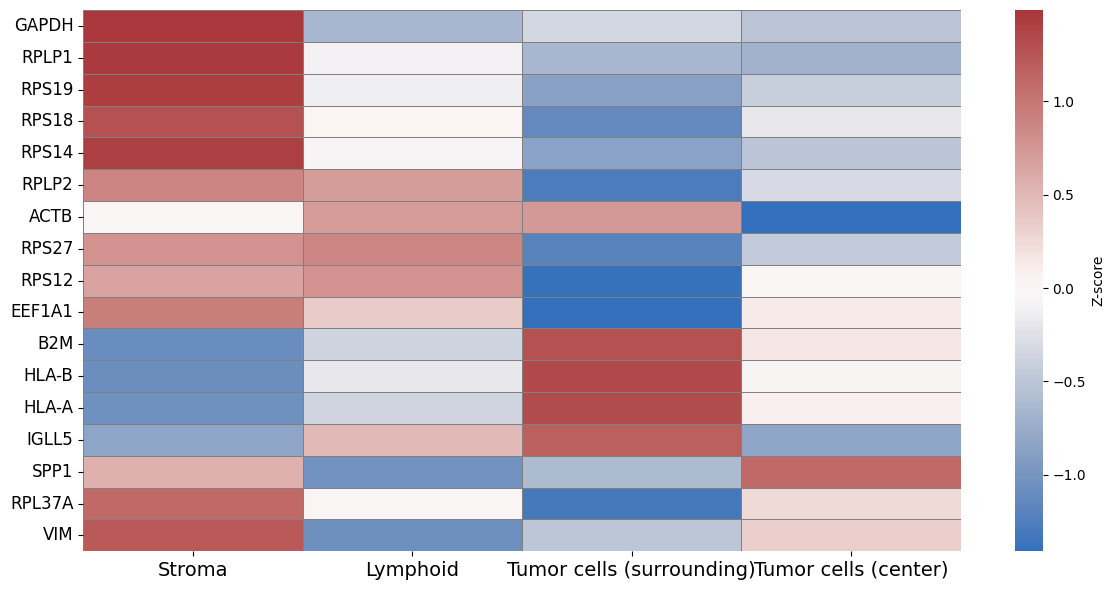

In [416]:
top_genes_ordered = []
for comp in snmf_signatures.columns:
    top_genes = snmf_signatures[comp].sort_values(ascending=False).head(N_TOP_GENES).index
    top_genes_ordered.extend([g for g in top_genes if g not in top_genes_ordered])

# Subset and reorder genes
snmf_top = snmf_signatures.loc[top_genes_ordered]

# ----- 2️⃣ Scale genes (row-wise z-score) -----
snmf_scaled = snmf_top.sub(snmf_top.mean(axis=1), axis=0).div(snmf_top.std(axis=1), axis=0)

# ----- 3️⃣ Fancy heatmap with Seaborn -----
plt.figure(figsize=(12, max(6, len(top_genes_ordered) * 0.25)))

# sns.set_style("white")
# sns.set_context("talk")

# Optionally, order components by annotation or clustering
sns.heatmap(
    snmf_scaled,
    cmap="vlag",          # diverging colormap for z-scores
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Z-score"},
    xticklabels=[annotation.get(c, c) for c in snmf_scaled.columns],
    yticklabels=snmf_scaled.index
)

plt.xticks(fontsize=14)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig(f"plots/K{K}_top_genes_heatmap.png", dpi=300)
plt.savefig(f"plots/K{K}_top_genes_heatmap.pdf", dpi=300)
plt.show()

In [417]:
for comp in snmf_signatures.columns:
    top_genes = snmf_signatures[comp].sort_values(ascending=False).head(N_TOP_GENES).index
    print(f"{annotation[comp]} variance: {snmf_scaled.loc[top_genes,comp].var()}")
    print(f"{annotation[comp]} range: {snmf_scaled.loc[top_genes,comp].max() - snmf_scaled.loc[top_genes,comp].min()}")
    print(f"{annotation[comp]} mean: {snmf_scaled.loc[top_genes,comp].mean()}")
    print()

Stroma variance: 0.005181978676182658
Stroma range: 0.19289556696202514
Stroma mean: 1.4143672603288069

Lymphoid variance: 0.03881292475719586
Lymphoid range: 0.5194420864417723
Lymphoid mean: 0.6821256093467167

Tumor cells (surrounding) variance: 0.06404523074588202
Tumor cells (surrounding) range: 0.6073338626608286
Tumor cells (surrounding) mean: 1.1735222775142735

Tumor cells (center) variance: 0.2645014395384311
Tumor cells (center) range: 1.415402090212765
Tumor cells (center) mean: 0.30083853085776285



In [418]:
adata.obs.columns = [c if c not in annotation.index.tolist() else annotation[c] for c in adata.obs.columns]
adata.var.columns = [c if c not in annotation.index.tolist() else annotation[c] for c in adata.var.columns]

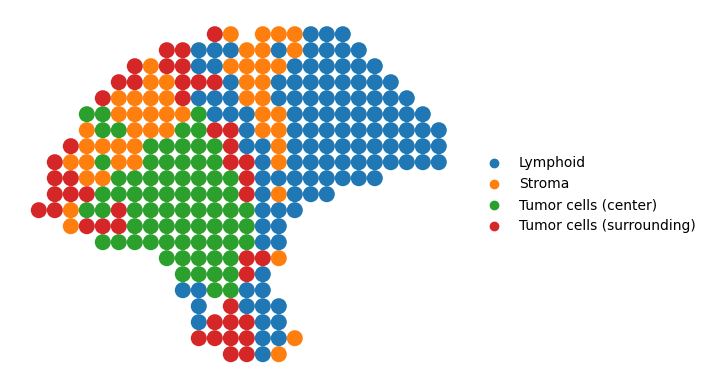

In [419]:
adata.obs["snmf_component"] = adata.obs[[annotation[c] for c in snmf_signatures.columns]].idxmax(axis=1)
sc.pl.spatial(adata, color="snmf_component", spot_size=1, frameon=False, title="", show=False)
plt.savefig(f"plots/K{K}_clustering.png", dpi=300)
plt.savefig(f"plots/K{K}_clustering.pdf", dpi=300)
plt.show()

<Figure size 1400x600 with 0 Axes>

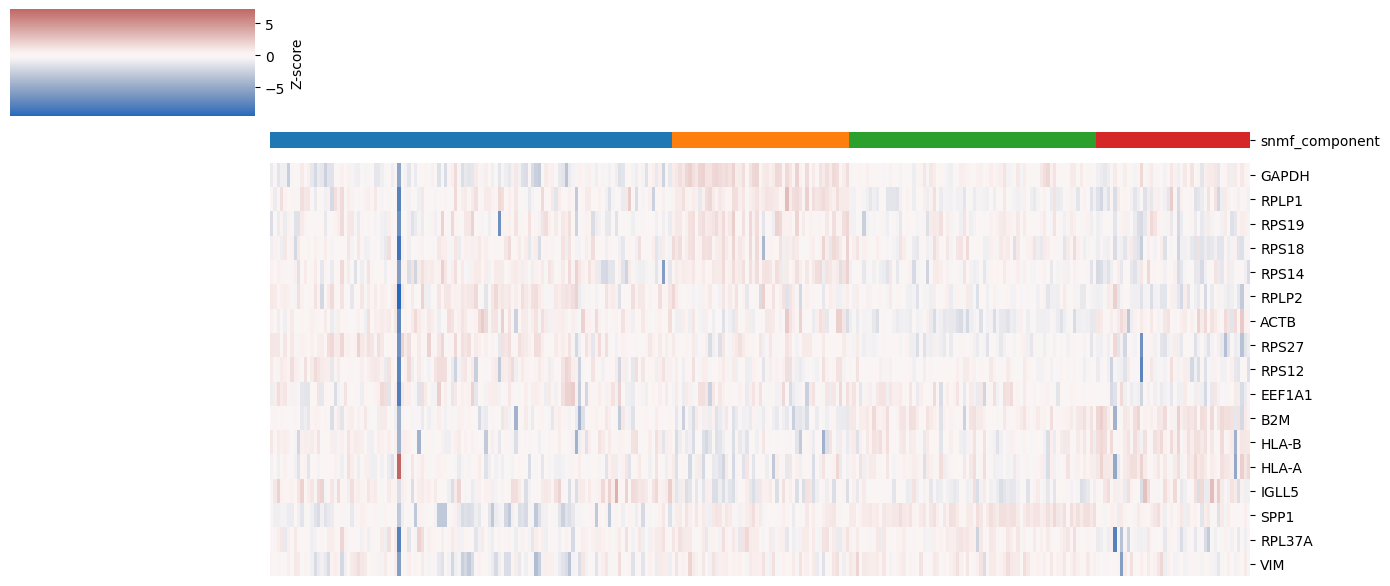

In [420]:
expr = pd.DataFrame(
    adata[:, top_genes_ordered].X.toarray(),
    index=adata.obs_names,
    columns=top_genes_ordered
).T

spot_order = adata.obs[adata.obs["snmf_component"] != "ambiguous"].sort_values("snmf_component").index
expr = expr[spot_order]

expr_scaled = expr.sub(expr.mean(axis=1), axis=0).div(expr.std(axis=1), axis=0)

cats = adata.obs["snmf_component"].cat.categories
colors = adata.uns["snmf_component_colors"]

lut = dict(zip(cats, colors))

col_colors = adata.obs["snmf_component"].map(lut)

plt.figure(figsize=(14, max(6, len(top_genes_ordered)*0.25)))

g = sns.clustermap(
    expr_scaled,
    row_cluster=False,
    col_cluster=False,
    cmap="vlag",
    center=0,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=expr_scaled.index,
    figsize=(14, max(6, len(top_genes_ordered)*0.25)),
    cbar_kws={"label": "Z-score"}
)

plt.tight_layout()
plt.show()

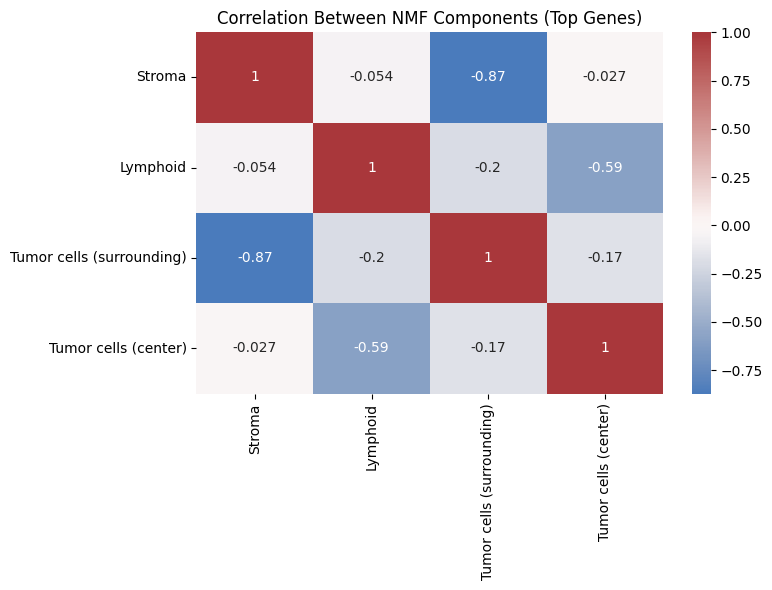

In [421]:
corr_matrix = snmf_scaled.corr()
labels = [annotation.get(c, c) for c in snmf_scaled.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, xticklabels=labels, yticklabels=labels, cmap="vlag", center=0)
plt.title("Correlation Between NMF Components (Top Genes)")

plt.tight_layout()
plt.savefig(f"plots/K{K}top_genes_corr.png", dpi=300)
plt.savefig(f"plots/K{K}top_genes_corr.pdf", dpi=300)
plt.show()

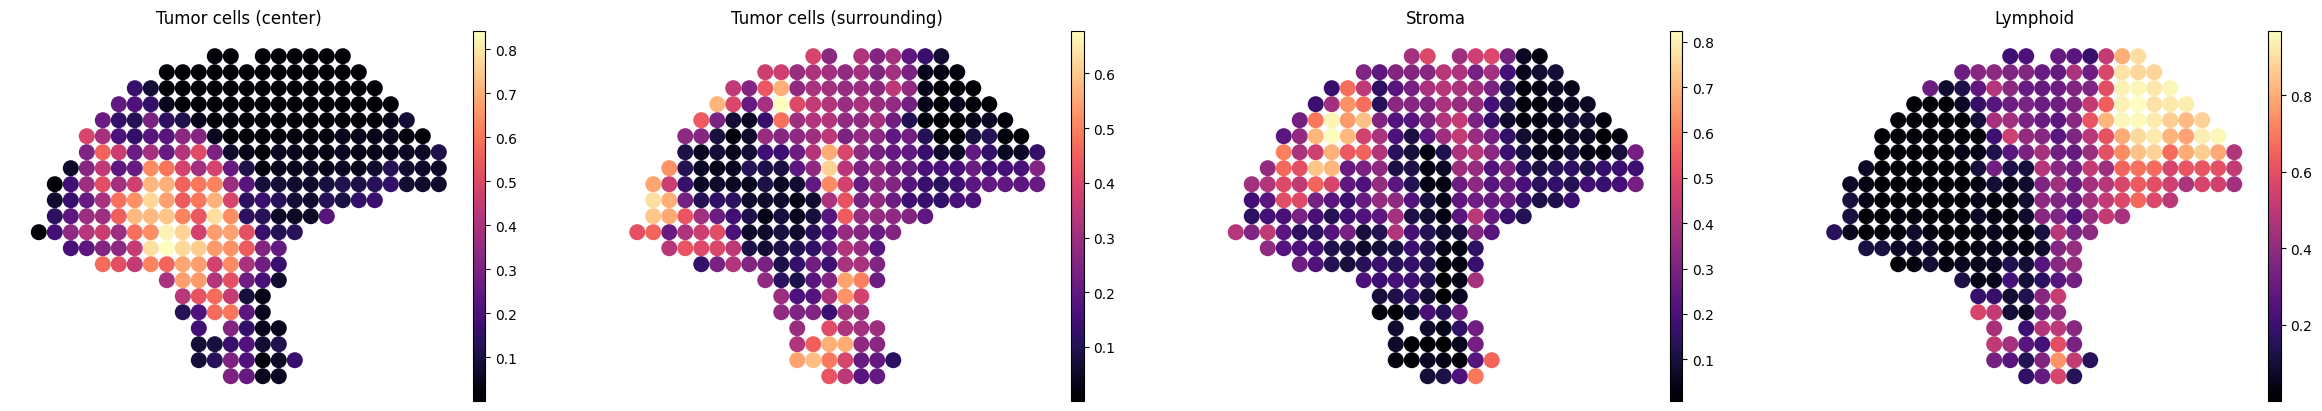

/tmp/ipykernel_284807/1711416709.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [422]:
colors = annotation.unique().tolist()

fig = sc.pl.spatial(
    adata,
    color=colors,
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=len(colors),
    return_fig=True,
    show=True
)

# Adjust spacing (important when many panels)
fig.tight_layout()

# Save in both formats
fig.savefig(f"plots/K{K}_spatial_plot.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_spatial_plot.pdf", bbox_inches="tight")

plt.close(fig)

In [423]:
TRANSITION_AREA_EXPRESSED_GENES = ["FTL","B2M","APOE","HLA-A","HLA-B","HLA-C"]

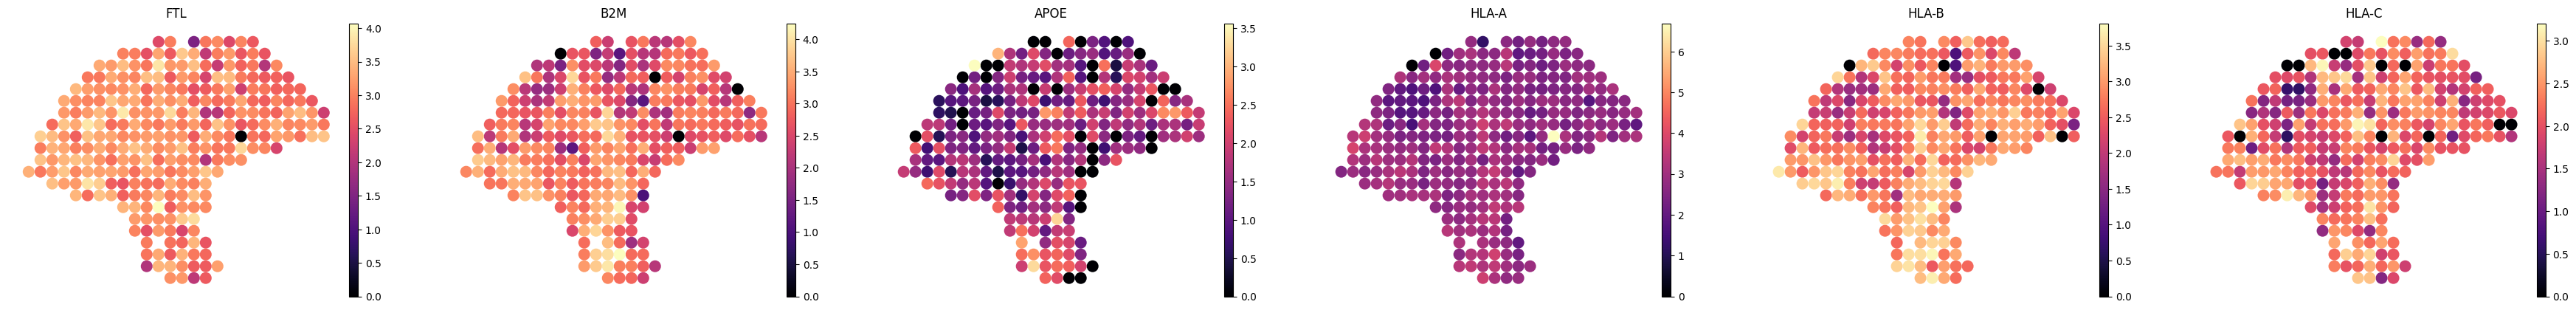

/tmp/ipykernel_284807/2385037767.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [424]:
fig = sc.pl.spatial(
    adata,
    color=TRANSITION_AREA_EXPRESSED_GENES,
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=len(TRANSITION_AREA_EXPRESSED_GENES),  # all in one row
    return_fig=True,
    show=True
)

# Optional: resize to fit many genes
fig.set_size_inches(4 * len(TRANSITION_AREA_EXPRESSED_GENES), 4)
fig.tight_layout()

# Save to PNG and PDF
fig.savefig(f"plots/K{K}_transition_genes_spatial.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_transition_genes_spatial.pdf", bbox_inches="tight")

plt.close(fig)

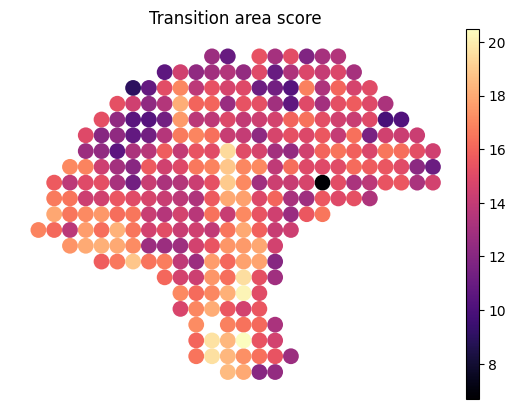

In [425]:
adata.obs["transition_area_score"] = adata[:,TRANSITION_AREA_EXPRESSED_GENES].X.sum(axis=1)

# Plot single spatial score
fig = sc.pl.spatial(
    adata,
    color="transition_area_score",
    spot_size=1,
    frameon=False,
    cmap="magma",
    title="Transition area score",
    return_fig=True,
    show=True
)

# Optional: resize figure for better visibility
fig.set_size_inches(6, 6)
fig.tight_layout()

# Save both PNG and PDF
fig.savefig(f"plots/K{K}_transition_area_score_spatial.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_transition_area_score_spatial.pdf", bbox_inches="tight")

plt.close(fig)

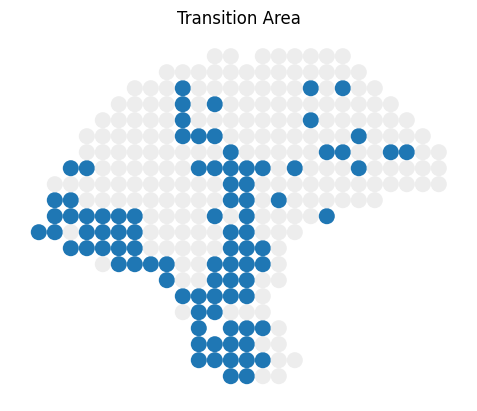

In [426]:
transition_score_threshold = 16
adata.obs["is_in_transition_area"] = np.where(
    adata.obs["transition_area_score"] > transition_score_threshold,
    "in_transition",
    "out_of_transition"  # use a string instead of None
)

# Optional: make "out_of_transition" white
palette = {
    "in_transition": sns.color_palette("tab20")[0],
    "out_of_transition": "#ededed"
}

fig = sc.pl.spatial(
    adata,
    color="is_in_transition_area",
    spot_size=1,
    frameon=False,
    palette=palette,
    legend_loc="none",
    title="Transition Area",
    return_fig=True,
    show=True
)

# Optional: resize
fig.set_size_inches(6, 6)
fig.tight_layout()

# Save figure
fig.savefig(f"plots/K{K}_transition_area_spatial.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_transition_area_spatial.pdf", bbox_inches="tight")

plt.close(fig)

In [427]:
from scipy.stats import spearmanr

for component in ["Tumor cells (surrounding)"]:
    rho, pval = spearmanr(adata.obs.loc[adata.obs["is_in_transition_area"] == "in_transition",component].values, adata.obs.loc[adata.obs["is_in_transition_area"] == "in_transition","transition_area_score"].values)
    print(f"Spearman correlation between '{component}' component and transition area score: {rho:.4f} (pval {pval:.4f})")

from scipy.stats import entropy

adata.obs["entropy"] = entropy(snmf_proportions, axis=1)
rho, pval = spearmanr(adata.obs.loc[adata.obs["is_in_transition_area"] == "in_transition","entropy"].values, adata.obs.loc[adata.obs["is_in_transition_area"] == "in_transition","transition_area_score"].values)
print(f"\nSpearman correlation between proportions entropy and transition area: {rho:.4f} (pval {pval:.4f})")

Spearman correlation between 'Tumor cells (surrounding)' component and transition area score: 0.5624 (pval 0.0000)

Spearman correlation between proportions entropy and transition area: 0.2018 (pval 0.0551)


# K=5 
## BayesSpace-like

In [428]:
adata = sc.read_h5ad("/scratch/lalonsoeste/PhD/SpatialTranscriptomics/data/spatial/BayesSpace/melanoma_thrane/processed/ST_mel1_rep2.h5ad")
adata.var_names_make_unique()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata

/scratch/lalonsoeste/envs/ST/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 293 × 16148
    obs: 'array_row', 'array_col', 'array_col_flipped'
    var: 'gene_id', 'ensemble_id'
    uns: 'log1p'
    obsm: 'spatial'

In [429]:
SIGNATURES = {
    "Tumor cells": ["PMEL"],
    "Fibroblasts": ["COL1A1"],
    "B cells": ["CD19", "MS4A1"],
    "T cells": ["CD2","CD3D","CD3E","CD3G","CD7"],
    "Macrophages": ["CD14","FCGR1A","FCGR1B"],
}

In [430]:
K = 5

In [431]:
snmf_proportions = pd.read_csv(f"./K{K}/SNMF/SNMF_proportions.csv", index_col=0)
snmf_proportions

,V1,V2,V3,V4,V5
7x15,0.153972,3.379900e-01,0.356935,0.120388,0.030715
7x16,0.241165,2.635902e-01,0.259546,0.157340,0.078360
7x17,0.439378,6.204702e-02,0.043830,0.261143,0.193603
7x18,0.098241,1.600677e-01,0.101100,0.163460,0.477131
8x13,0.226912,1.116450e-01,0.405918,0.227123,0.028401
...,...,...,...,...,...
27x18,0.091942,4.697952e-03,0.083208,0.356231,0.463921
27x19,0.044722,1.713644e-03,0.177189,0.282192,0.494183
27x20,0.180331,1.179278e-04,0.023703,0.502040,0.293808
27x21,0.571735,1.102414e-06,0.007096,0.364151,0.057017


In [432]:
adata.obs = pd.concat([adata.obs, snmf_proportions], axis=1)

In [433]:
snmf_signatures = pd.read_csv(f"./K{K}/SNMF/signatures.csv", index_col=0)
snmf_signatures

,V1,V2,V3,V4,V5
PSME2,4.447504e+00,2.301499e+00,1.573209e+01,6.860616,2.597574
CUEDC1,3.027134e-01,7.238853e-01,4.602129e-01,0.015874,0.645284
RPLP1,9.025826e+01,6.242096e+01,2.868254e+01,63.621973,233.241011
TM9SF3,1.559318e+00,1.729010e+00,1.670180e+00,2.173441,0.518193
DEF8,1.622941e+00,1.465461e+00,1.119922e+00,1.364098,2.298179
...,...,...,...,...,...
MICU3,2.747248e-01,5.198973e-20,0.000000e+00,0.000000,0.466426
CTAGE5,3.191667e-01,3.814920e-02,8.802337e-21,0.000000,0.220406
ALPL,2.129374e-01,0.000000e+00,0.000000e+00,0.426286,0.000000
GPC3,9.023129e-21,0.000000e+00,0.000000e+00,0.829798,0.000000


In [434]:
adata.var = pd.concat([adata.var, snmf_signatures], axis=1)

In [451]:
import numpy as np

snmf_z = (snmf_signatures - snmf_signatures.mean(axis=0)) / snmf_signatures.std(axis=0)

score_table = pd.DataFrame(index=SIGNATURES.keys(),
                           columns=snmf_z.columns,
                           dtype=float)

for comp in snmf_z.columns:
    for celltype, markers in SIGNATURES.items():
        valid = [g for g in markers if g in snmf_z.index]
        if len(valid) > 0:
            score_table.loc[celltype, comp] = (
                snmf_z.loc[valid, comp].mean() - snmf_z[comp].mean()
            )
        else:
            score_table.loc[celltype, comp] = -np.inf

# --------------------------------------------------
# 2️⃣ Annotation function
# --------------------------------------------------
def unique_assignment(score_table, threshold=0.2):
    
    # For each component, sort cell types by descending score
    ranked = {
        comp: score_table[comp].sort_values(ascending=False).index.tolist()
        for comp in score_table.columns
    }
    
    assigned_celltypes = set()
    final_assignment = {}
    
    # Sort components by their BEST score (descending)
    components_order = sorted(
        score_table.columns,
        key=lambda c: score_table[c].max(),
        reverse=True
    )
    
    for comp in components_order:
        for celltype in ranked[comp]:
            
            if score_table.loc[celltype, comp] < threshold:
                final_assignment[comp] = "ambiguous"
                break
            
            if celltype not in assigned_celltypes:
                final_assignment[comp] = celltype
                assigned_celltypes.add(celltype)
                break
        else:
            final_assignment[comp] = "ambiguous"
    
    return pd.Series(final_assignment)

# --------------------------------------------------
# 3️⃣ Apply to all components
# --------------------------------------------------
annotation = unique_assignment(score_table)

print(annotation)

V4    Fibroblasts
V2    Tumor cells
V1        B cells
V5      ambiguous
V3    Macrophages
dtype: object


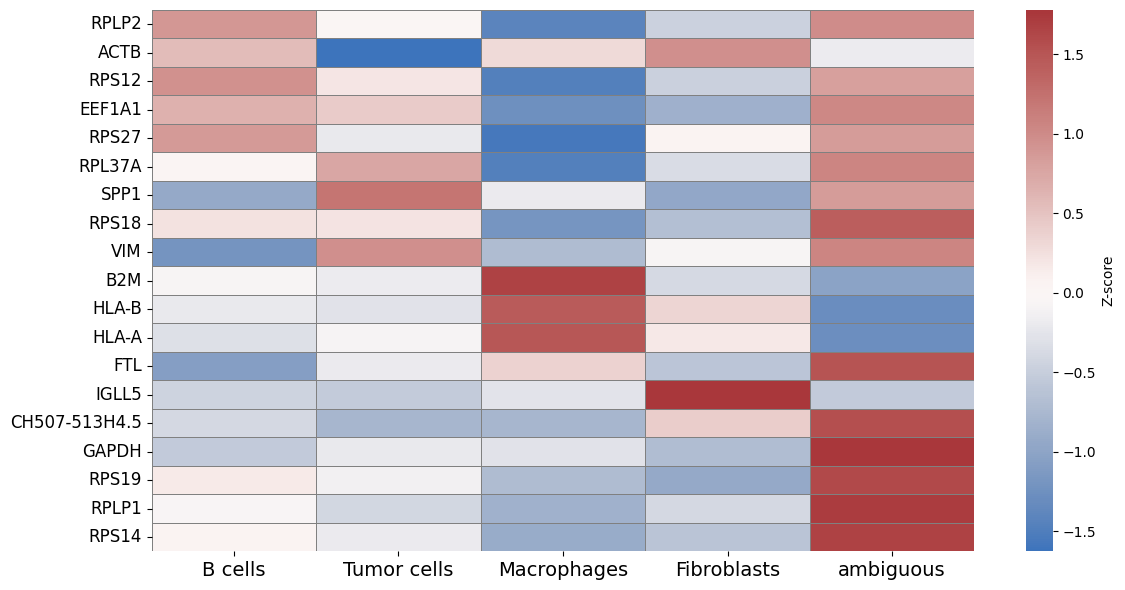

In [436]:
top_genes_ordered = []
for comp in snmf_signatures.columns:
    top_genes = snmf_signatures[comp].sort_values(ascending=False).head(N_TOP_GENES).index
    top_genes_ordered.extend([g for g in top_genes if g not in top_genes_ordered])

# Subset and reorder genes
snmf_top = snmf_signatures.loc[top_genes_ordered]

# ----- 2️⃣ Scale genes (row-wise z-score) -----
snmf_scaled = snmf_top.sub(snmf_top.mean(axis=1), axis=0).div(snmf_top.std(axis=1), axis=0)

# ----- 3️⃣ Fancy heatmap with Seaborn -----
plt.figure(figsize=(12, max(6, len(top_genes_ordered) * 0.25)))

# sns.set_style("white")
# sns.set_context("talk")

# Optionally, order components by annotation or clustering
sns.heatmap(
    snmf_scaled,
    cmap="vlag",          # diverging colormap for z-scores
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Z-score"},
    xticklabels=[annotation.get(c, c) for c in snmf_scaled.columns],
    yticklabels=snmf_scaled.index
)

plt.xticks(fontsize=14)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig(f"plots/K{K}_top_genes_heatmap.png", dpi=300)
plt.savefig(f"plots/K{K}_top_genes_heatmap.pdf", dpi=300)
plt.show()

In [437]:
for comp in snmf_signatures.columns:
    top_genes = snmf_signatures[comp].sort_values(ascending=False).head(N_TOP_GENES).index
    print(f"{annotation[comp]} variance: {snmf_scaled.loc[top_genes,comp].var()}")
    print(f"{annotation[comp]} range: {snmf_scaled.loc[top_genes,comp].max() - snmf_scaled.loc[top_genes,comp].min()}")
    print(f"{annotation[comp]} mean: {snmf_scaled.loc[top_genes,comp].mean()}")
    print()

B cells variance: 0.027042889613437152
B cells range: 0.3819042402767642
B cells mean: 0.7850271709279193

Tumor cells variance: 0.25278671022792326
Tumor cells range: 1.2003534134053426
Tumor cells mean: 0.6318837636199086

Macrophages variance: 0.44792571674410886
Macrophages range: 1.3757442671617452
Macrophages mean: 1.052652971700012

Fibroblasts variance: 0.7414709766216514
Fibroblasts range: 2.2414481153731574
Fibroblasts mean: 0.5482503823555195

ambiguous variance: 0.01738630715494073
ambiguous range: 0.3346469656854225
ambiguous mean: 1.6322662350991066



In [438]:
adata.obs.columns = [c if c not in annotation.index.tolist() else annotation[c] for c in adata.obs.columns]
adata.var.columns = [c if c not in annotation.index.tolist() else annotation[c] for c in adata.var.columns]

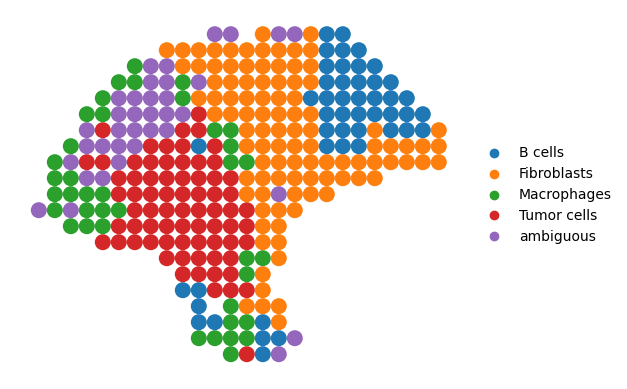

In [439]:
adata.obs["snmf_component"] = adata.obs[[annotation[c] for c in snmf_signatures.columns]].idxmax(axis=1)
sc.pl.spatial(adata, color="snmf_component", spot_size=1, frameon=False, title="", show=False)
plt.savefig(f"plots/K{K}_clustering.png", dpi=300)
plt.savefig(f"plots/K{K}_clustering.pdf", dpi=300)
plt.show()

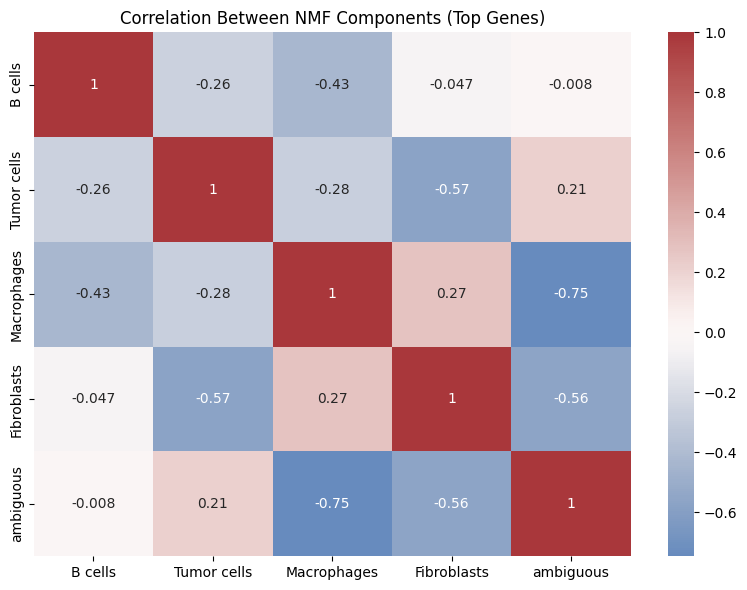

In [440]:
corr_matrix = snmf_scaled.corr()
labels = [annotation.get(c, c) for c in snmf_scaled.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, xticklabels=labels, yticklabels=labels, cmap="vlag", center=0)
plt.title("Correlation Between NMF Components (Top Genes)")

plt.tight_layout()
plt.savefig(f"plots/K{K}top_genes_corr.png", dpi=300)
plt.savefig(f"plots/K{K}top_genes_corr.pdf", dpi=300)
plt.show()

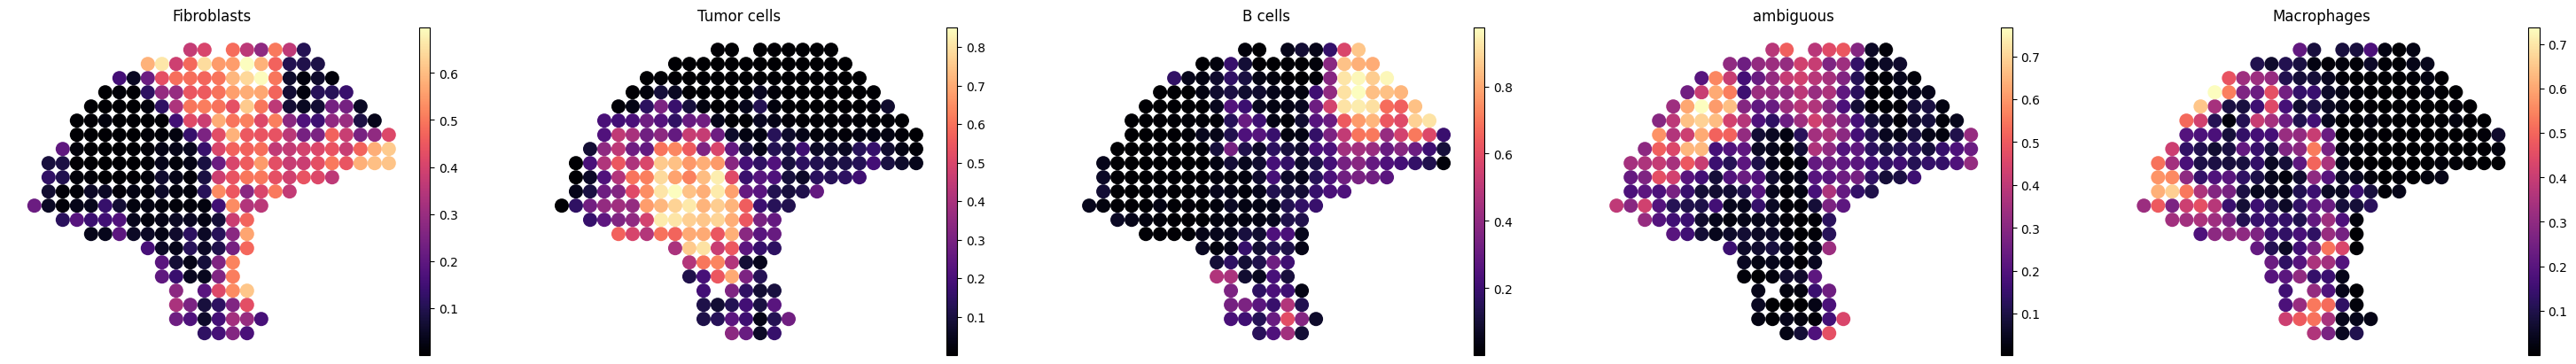

/tmp/ipykernel_284807/1711416709.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [441]:
colors = annotation.unique().tolist()

fig = sc.pl.spatial(
    adata,
    color=colors,
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=len(colors),
    return_fig=True,
    show=True
)

# Adjust spacing (important when many panels)
fig.tight_layout()

# Save in both formats
fig.savefig(f"plots/K{K}_spatial_plot.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_spatial_plot.pdf", bbox_inches="tight")

plt.close(fig)

In [442]:
TRANSITION_AREA_EXPRESSED_GENES = ["FTL","B2M","APOE","HLA-A","HLA-B","HLA-C"]

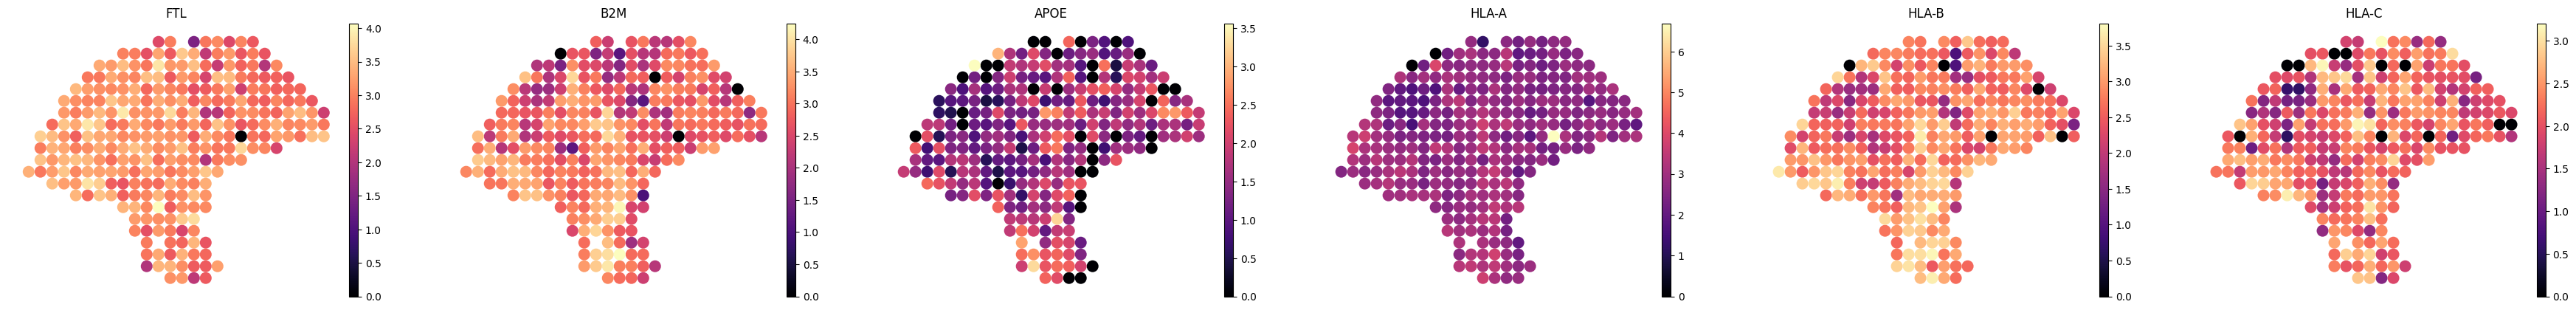

/tmp/ipykernel_284807/2385037767.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [443]:
fig = sc.pl.spatial(
    adata,
    color=TRANSITION_AREA_EXPRESSED_GENES,
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=len(TRANSITION_AREA_EXPRESSED_GENES),  # all in one row
    return_fig=True,
    show=True
)

# Optional: resize to fit many genes
fig.set_size_inches(4 * len(TRANSITION_AREA_EXPRESSED_GENES), 4)
fig.tight_layout()

# Save to PNG and PDF
fig.savefig(f"plots/K{K}_transition_genes_spatial.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_transition_genes_spatial.pdf", bbox_inches="tight")

plt.close(fig)

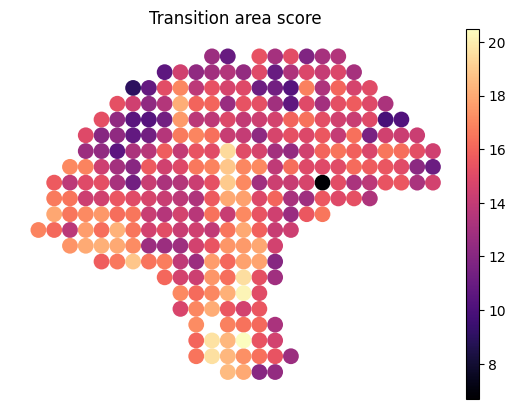

In [444]:
adata.obs["transition_area_score"] = adata[:,TRANSITION_AREA_EXPRESSED_GENES].X.sum(axis=1)

# Plot single spatial score
fig = sc.pl.spatial(
    adata,
    color="transition_area_score",
    spot_size=1,
    frameon=False,
    cmap="magma",
    title="Transition area score",
    return_fig=True,
    show=True
)

# Optional: resize figure for better visibility
fig.set_size_inches(6, 6)
fig.tight_layout()

# Save both PNG and PDF
fig.savefig(f"plots/K{K}_transition_area_score_spatial.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_transition_area_score_spatial.pdf", bbox_inches="tight")

plt.close(fig)

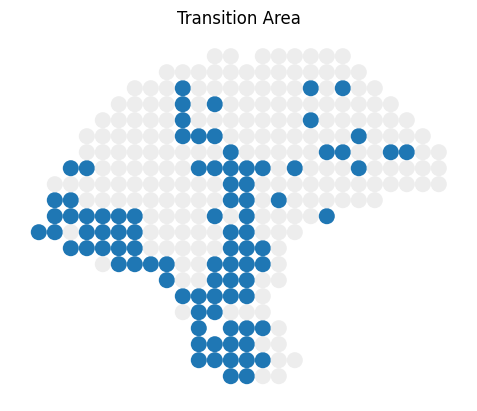

In [445]:
adata.obs["is_in_transition_area"] = np.where(
    adata.obs["transition_area_score"] > transition_score_threshold,
    "in_transition",
    "out_of_transition"  # use a string instead of None
)

# Optional: make "out_of_transition" white
palette = {
    "in_transition": sns.color_palette("tab20")[0],
    "out_of_transition": "#ededed"
}

fig = sc.pl.spatial(
    adata,
    color="is_in_transition_area",
    spot_size=1,
    frameon=False,
    palette=palette,
    legend_loc="none",
    title="Transition Area",
    return_fig=True,
    show=True
)

# Optional: resize
fig.set_size_inches(6, 6)
fig.tight_layout()

# Save figure
fig.savefig(f"plots/K{K}_transition_area_spatial.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_transition_area_spatial.pdf", bbox_inches="tight")

plt.close(fig)

In [446]:
from scipy.stats import spearmanr

for component in ["Macrophages"]:
    rho, pval = spearmanr(adata.obs.loc[adata.obs["is_in_transition_area"] == "in_transition",component].values, adata.obs.loc[adata.obs["is_in_transition_area"] == "in_transition","transition_area_score"].values)
    print(f"Spearman correlation between '{component}' component and transition area score: {rho:.4f} (pval {pval:.4f})")

from scipy.stats import entropy

adata.obs["entropy"] = entropy(snmf_proportions, axis=1)
rho, pval = spearmanr(adata.obs.loc[adata.obs["is_in_transition_area"] == "in_transition","entropy"].values, adata.obs.loc[adata.obs["is_in_transition_area"] == "in_transition","transition_area_score"].values)
print(f"\nSpearman correlation between proportions entropy and transition area: {rho:.4f} (pval {pval:.4f})")

Spearman correlation between 'Macrophages' component and transition area score: 0.5779 (pval 0.0000)

Spearman correlation between proportions entropy and transition area: 0.3441 (pval 0.0008)
